# AG-HYPOPT · Trial 18

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Seventeen trials recorded; best is trial 14 (0.0149), tied with trial 12 (0.0150). Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182, 10 0.0301, 11 0.0174, 12 0.0150, 13 0.0339, 14 0.0149, 15 0.0199, 16 0.0294, 17 0.0203. Trials 05/07/.../17 are the same plateau point (lr_mu ~27, sigma_ref ~6.05-6.3, lr_gamma ~0.42, gamma_anneal ~0.37-0.43) spanning 0.0149-0.0339; mu is fixed at 14.4-17.2% and gamma (9.5-21.4%) drives the spread via the erratic low-count Trans05 scan. Repeating the plateau now only re-samples that noise, so the marginal value of another plateau point is near zero. The campaign is fully converged. We are in the TPE phase (18th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_18'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (17/5 trials)
ID |     ei | params
 1 | 3.9961 | {"gamma_anneal": 0.4074406807338926, "lr_gamma": 0.41685967261731344, "lr_mu": 27.10278331142378, "sigma_ref": 6.155225746619987}
 2 | 3.9740 | {"gamma_anneal": 0.45231676021999767, "lr_gamma": 0.41799535726515047, "lr_mu": 27.04658501385842, "sigma_ref": 6.1901521326417965}
 3 | 3.9885 | {"gamma_anneal": 0.40881719821288565, "lr_gamma": 0.4180133891927653, "lr_mu": 20.65415277541107, "sigma_ref": 6.140909910940951}
 4 | 3.9992 | {"gamma_anneal": 0.3893330259032311, "lr_gamma": 0.4178026973958246, "lr_mu": 26.971291134283998, "sigma_ref": 6.097077529275438}
 5 | 3.9876 | {"gamma_anneal": 0.4252273337476844, "lr_gamma": 0.4174418913850605, "lr_mu": 27.14631125866688, "sigma_ref": 19.56527005480905}
 6 | 3.1765 | {"gamma_anneal": 0.012773009690492554, "lr_gamma": 0.5157960028814634, "lr_mu": 27.000932941356705, "sigma_ref": 6.054652170062326}
 7 | 3.7993 | {"gamma_anneal": 0.016876708810755287, "lr_gamma": 0.801511038505227

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 14 (0.0149). The plateau (lr_mu ~27, sigma_ref ~6.1, lr_gamma ~0.42, gamma_anneal ~0.4) is converged: ten-plus runs differ only by Trans05 gamma noise, so another plateau draw (the top-ei #4, sigma_ref 6.097) would add essentially no information. Meanwhile the batch contains a direction never probed: candidate 6 (ei 3.1765) has gamma_anneal 0.0128 - essentially no annealing - with lr_mu 27.00, sigma_ref 6.055 and lr_gamma 0.516. Trial 02 (gamma_anneal 0.20) is among the best pre-plateau points, and trial 04 (gamma_anneal 0.71) is among the worst, so low gamma_anneal is the favourable side of the range; testing the extreme (approximately zero) on the optimal mu/sigma_ref regime is a genuinely informative experiment where a plateau repeat is not. I accept the lower ei for the chance to either break the plateau or rule out the extreme. I choose candidate 6.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.012773009690492554, 'lr_gamma': 0.5157960028814634, 'lr_mu': 27.000932941356705, 'sigma_ref': 6.054652170062326}
Running  1nW Trans05 ... 

μ 9.39 -> 6.92 | γ 8.5 -> 7.43 | NLL 1.26


Running  1nW Trans20 ... 

μ 17.32 -> 15.91 | γ 8.5 -> 8.49 | NLL 2.71


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 101.22 | γ 14.1 -> 14.24 | NLL 3.49


Running 3nW Trans100 ... 

μ 175.71 -> 166.55 | γ 14.1 -> 14.17 | NLL 2.91



Total: 7.0 min


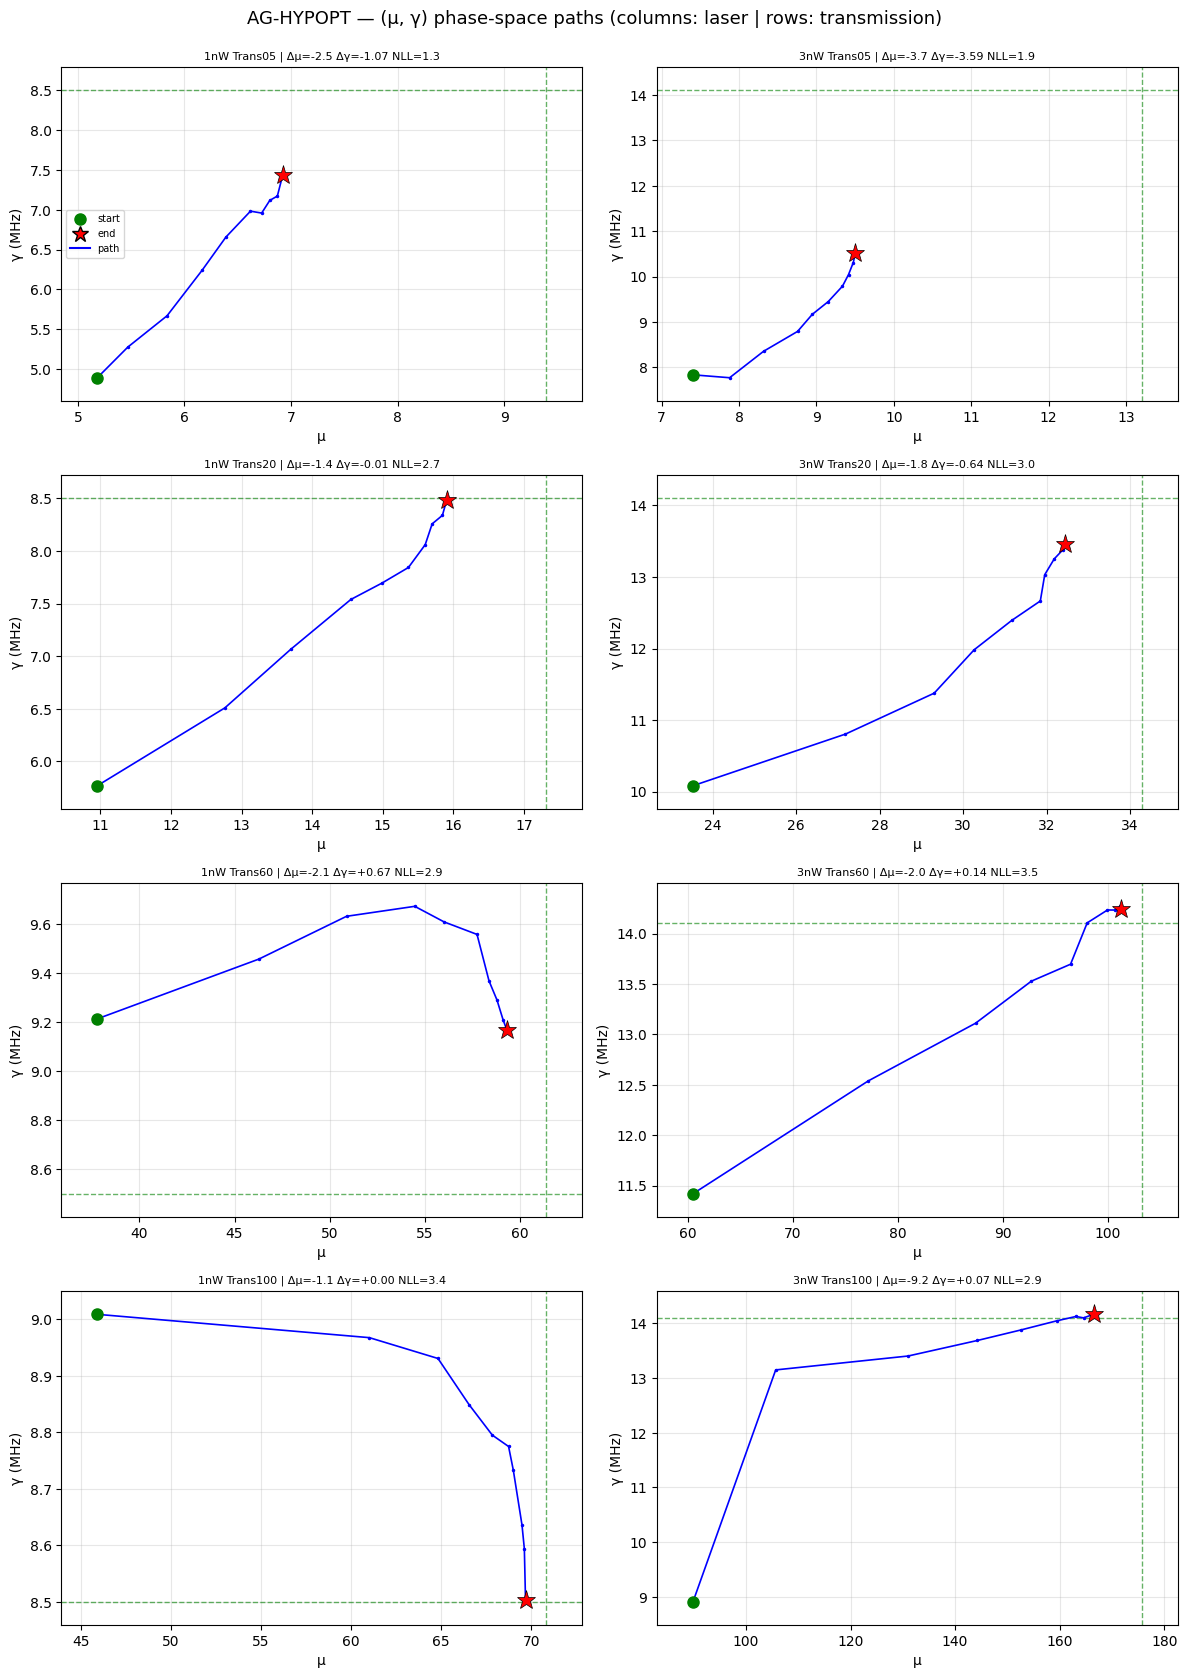

trial finished in 7.0 min
objective = 0.0157 ± 0.0069
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.92   -26.3 |     8.50    7.43   -12.6
1nW Trans20    17.32   15.91    -8.1 |     8.50    8.49    -0.1
1nW Trans60    61.37   59.31    -3.4 |     8.50    9.17    +7.9
1nW Trans100   70.82   69.68    -1.6 |     8.50    8.50    +0.0
3nW Trans05    13.20    9.50   -28.0 |    14.10   10.51   -25.5
3nW Trans20    34.28   32.44    -5.4 |    14.10   13.46    -4.6
3nW Trans60   103.20  101.22    -1.9 |    14.10   14.24    +1.0
3nW Trans100  175.71  166.55    -5.2 |    14.10   14.17    +0.5

μ: RMSE 3.848 (rel 14.2%, bias -2.969) | γ: RMSE 1.365 (rel 10.5%, bias -0.554)


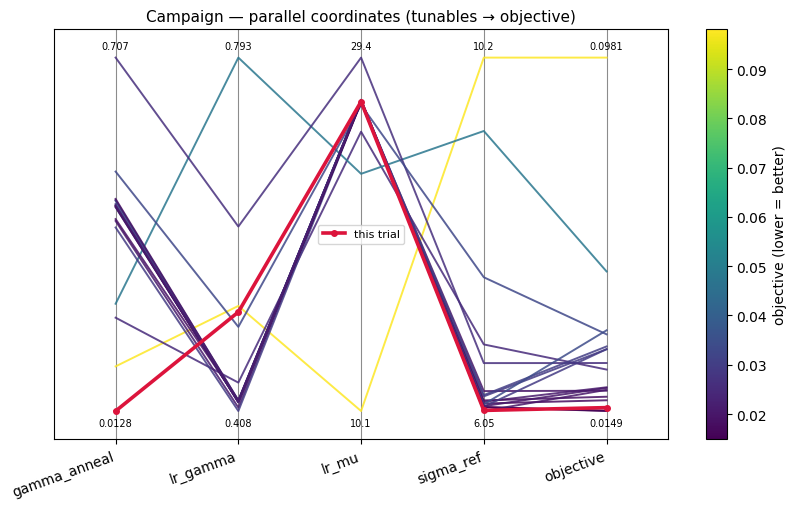

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 18 (gamma_anneal 0.0128, lr_mu 27.00, sigma_ref 6.055, lr_gamma 0.516) was a deliberate probe of the gamma_anneal extreme (near-zero annealing) on the optimal mu/sigma_ref regime, taken instead of a plateau repeat. It ran 7.0 min and scored 0.0157 +/- 0.0069, the second-best objective after trial 14 (0.0149). Crucially it gave the best mu yet: rel RMSE 14.2% (bias -3.0; previous best 14.4%), with gamma 10.5% (near the best). So near-zero gamma_anneal is favourable - it slightly improved mu and kept gamma good - consistent with the earlier hint that low gamma_anneal (trial 02, 0.20) beat high (trial 04, 0.71). Trial 14 (0.0149) is still nominally best, but trial 18 shows the anneal extreme is not harmful and may help mu; this is the most informative trial in a while and points to the low-anneal corner.

**Summary:** Trial 18 (gamma_anneal 0.013, lr_mu 27.00, sigma_ref 6.055, lr_gamma 0.516), a deliberate probe of near-zero annealing, scored 0.0157 +/- 0.0069 - second-best overall - with the best mu yet (14.2%) and good gamma (10.5%).
**Key insight:** Near-zero gamma_anneal (0.013) on the optimal mu/sigma_ref regime gave the campaign's best mu (14.2%) without hurting gamma, so the low-anneal corner is favourable and holds the remaining gains.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 18 (gamma_anneal 0.013, lr_mu 27.00, sigma_ref 6.055, lr_gamma 0.516), a deliberate probe of near-zero annealing, scored 0.0157 +/- 0.0069 - second-best overall - with the best mu yet (14.2%) and good gamma (10.5%).'
KEY_INSIGHT = 'Near-zero gamma_anneal (0.013) on the optimal mu/sigma_ref regime gave the campaign best mu (14.2%) without hurting gamma, so the low-anneal corner is favourable and holds the remaining gains.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_18 | current best: trial_14


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_19.ipynb. Open it and follow its cells from the top.
